# Импорт библиотек

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import *
from scipy.optimize import fsolve

# Задание 1

### Отделите корни заданного уравнения, пользуясь графическим методом и с применением одного из инструментальных средств.

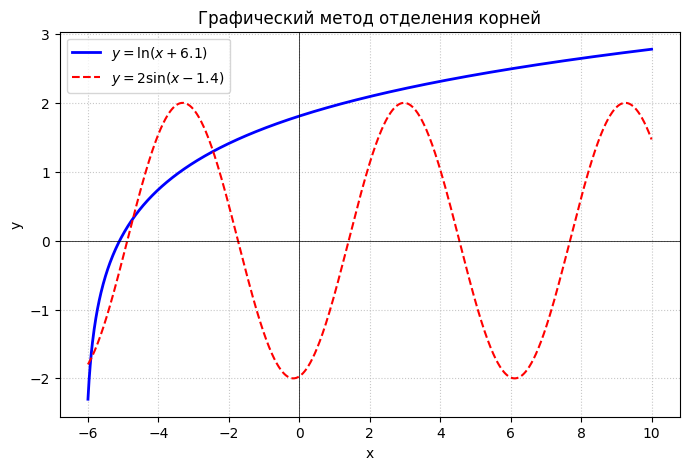

In [ ]:
def f1(x):
    return np.log(x + 6.1)

def f2(x):
    return 2 * np.sin(x - 1.4)


# Если f_diff = 0, то корень найден.
def f_diff(x):
    return f1(x) - f2(x)


# Диапазон x (с учетом области определения ln: x > -6.1)
x_plot = np.linspace(-6.0, 10, 1000)


# Графики функций
plt.figure(figsize=(8, 5))
plt.plot(x_plot, f1(x_plot), label=r'$y = \ln(x + 6.1)$', color='blue', linewidth=2)
plt.plot(x_plot, f2(x_plot), label=r'$y = 2\sin(x - 1.4)$', color='red', linestyle='--')


# Оформление графика
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Графический метод отделения корней')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

На графике видно, что корни  находятся по оси х примерно в окрестностях -6; -5 и -2. Я использую библиотеку SciPy для вывода корней.

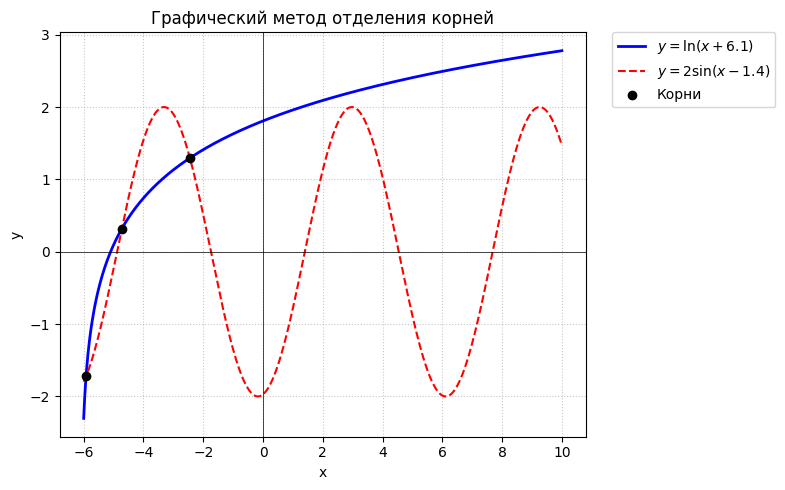

Найденные корни уравнения ln(x + 6.1) = 2*sin(x - 1.4): 
x1 ≈ -5.921
x2 ≈ -4.722
x3 ≈ -2.446


In [ ]:
initial_guesses = [-6, -5, -2]
roots = fsolve(f_diff, initial_guesses)
unique_roots = np.unique(np.round(roots, 5)) # На всякий случай, если вдруг появятся дубликаты во время расчётов.


x_plot = np.linspace(-6.0, 10, 1000)

# Графики функций
plt.figure(figsize=(8, 5))
plt.plot(x_plot, f1(x_plot), label=r'$y = \ln(x + 6.1)$', color='blue', linewidth=2)
plt.plot(x_plot, f2(x_plot), label=r'$y = 2\sin(x - 1.4)$', color='red', linestyle='--')


# Отмечаю корни на графике точками
plt.scatter(unique_roots, f1(unique_roots), color='black', zorder=5, label='Корни')


# Оформление графика
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.title('Графический метод отделения корней')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout() # Чтобы надписи не перемешивались.
plt.show()


print("Найденные корни уравнения ln(x + 6.1) = 2*sin(x - 1.4): ")
for i, root in enumerate(unique_roots, 1):
    print(f"x{i} ≈ {root:.3f}")


Уравнение имеет три действительных корня.
Эти значения лежат в области определения логарифма, а именно x > -6.1, что подтверждает их корректность, как решений.

Графически показано, что кривая логарифма пересекает синусоид в трёх точках на интервале примерно (−6.1, -2). Такое число корней отражает сочетание медленного подъёма логарифма и осциллирующего характера правой части, благодаря которому график 2sin(x−1.4) несколько раз «перескакивает» через логарифмическую кривую.

Графический метод позволил отделить корни и приближённо указать их расположение, что удобно для дальнейшего уточнения корней численными методами на каждого из полученных отрезков. Но в заданиях дальше указано найти один корень. Потому для проверки корректности методов я буду искать корень на одном и том же интервале и сравнивать результаты разных методов.

# Задание 2

### По методу половинного деления вычислите один корень заданного уравнения с точностью до 10^-3.

In [ ]:
# Определяю функцию f(x) = ln(x + 6.1) - 2*sin(x - 1.4)
def f(x):
    return np.log(x + 6.1) - 2 * np.sin(x - 1.4)

def bisection_method(a, b, eps):

    # Проверка условия теоремы Больцано-Коши
    if f(a) * f(b) > 0:
        print("На данном отрезке корней нет или их четное количество")
        return None
    

    # Списки для таблицы
    it = []
    ass = []
    bs = []
    result = []

    
    iteration = 0
    while (b - a) / 2 > eps:
        
        mid = (a + b) / 2

        # Выбираю половину отрезка, на которой функция меняет знак
        if f(a) * f(mid) < 0:
            b = mid
        else:
            a = mid
        

        # Добавляю в списки данные
        ass.append(round(a, 3))
        bs.append(round(b, 3))
        result.append(round(mid, 3))
        iteration += 1
        it.append(iteration)
    

    # Создание таблицы
    data = {'Итерации': it, 'a': ass, 'b': bs, 'result': result}
    df = pd.DataFrame(data)
    df = df.set_index('Итерации')

    return df, (a + b) / 2

# Беру интервал [-6;-5], потому что на этом интервале должен быть только 1 корень.
a, b = -6, -5
epsilon = 1e-3 # Точность

df, root = bisection_method(a, b, epsilon)

if root is not None:
    print(df)
    print(f"\nКорень уравнения: {root:.3f}")

              a      b  result
Итерации                      
1        -6.000 -5.500  -5.500
2        -6.000 -5.750  -5.750
3        -6.000 -5.875  -5.875
4        -5.938 -5.875  -5.938
5        -5.938 -5.906  -5.906
6        -5.922 -5.906  -5.922
7        -5.922 -5.914  -5.914
8        -5.922 -5.918  -5.918
9        -5.922 -5.920  -5.920

Корень уравнения: -5.921


Метод половинного деления позволил уточнить один из корней уравнения ln(x+6.1)=2sin(x−1.4). Корень уравнение с точностью 10^-3, и его найденное значение совпало с одним из корней, полученных ранее при графическом отделении корней, а именно x1≈−5.921. Это подтверждает корректность результата.

Метод половинного деления показал устойчивую сходимость и стабильный результат, поскольку он основан на поиске изменения знака функции на отрезке и гарантированно находит корень, если функция непрерывна и на концах отрезка значения имеют разные знаки.


# Задание 3

### Вычислите один корень заданного уравнения с помощью программы для компьютера с точностью до 10^-6, используя метод простой итерации.

In [ ]:
def phi(x):

    # Преобразованная функция f(x) = ln(x + 6.1) - 2*sin(x - 1.4) в вид x = exp(2*sin(x - 1.4)) - 6.1
    return np.exp(2 * np.sin(x - 1.4)) - 6.1

def simple_iteration(x0, eps):


    # Списки для данных
    it = []
    x_olds = []
    x_news = []
    
    x_old = x0
    x_new = phi(x_old)
    iterations = 1

    it.append(iterations)
    x_olds.append(x_old)
    x_news.append(x_new)

    while abs(x_new - x_old) > eps:
        x_old = x_new
        x_new = phi(x_old)
        iterations += 1


        # Добавление данных в списки
        it.append(iterations)
        x_olds.append(x_old)
        x_news.append(x_new)
    
    # Создание таблицы
    data = {'Итерации': it, 'x_old': x_olds, 'x_new': x_news}
    df = pd.DataFrame(data)
    df = df.set_index('Итерации')
    return df, x_new

# Начальные параметры
x_start = -6.0  
precision = 1e-6    # Точность

simple_iteration(x_start, precision)
df, root = simple_iteration(x_start, precision)

print(df)
print(f"\nКорень уравнения: {root:.6f}")

             x_old     x_new
Итерации                    
1        -6.000000 -5.934273
2        -5.934273 -5.923763
3        -5.923763 -5.921897
4        -5.921897 -5.921560
5        -5.921560 -5.921499
6        -5.921499 -5.921488
7        -5.921488 -5.921486
8        -5.921486 -5.921485

Корень уравнения: -5.921485


Метод простой итерации вывел тот же корень уравнения ln(x+6.1)=2sin(x−1.4). Корень уравнения с точностью 10^−6, и найденное значение полностью совпало с тем, который был получен ранее. Это подтверждает согласованность результатов разных подходов.

Метод простой итерации продемонстрировал высокую точность и стабильную сходимость к корню, так как была выбрана подходящая итерационная формула и начальное приближение из уже отделённого отрезка.
Достижение точности 10^−6 говорит о том, что метод эффективно работает на данном уравнении и позволяет получать достаточно надёжные результаты для практического использования.

# Задание 4 

### Вычислите один корень заданного уравнения с помощью программы для компьютера с точностью до 10^-6, используя комбинированный метод хорд и касательных.

In [ ]:
def f(x):
    return np.log(x + 6.1) - 2 * np.sin(x - 1.4)

def df(x):
    return 1 / (x + 6.1) - 2 * np.cos(x - 1.4)  # Производная функция

def df2(x):
    return -1 / (x + 6.1)**2 + 2 * np.sin(x - 1.4)  # Вторая производная функции

def solve_combined(a, b, eps):

    # Определяю, с какой стороны касательная (x_k), а с какой хорда (x_n)
    if f(a) * df2(a) > 0:
        x_k, x_n = a, b
    else:
        x_k, x_n = b, a
    
    # Списки для таблицы
    it = []
    x_ns = []
    x_ks = []

    iteration = 0
    while abs(x_n - x_k) > eps:

        # Временно создаю новые переменные, чтобы изменения не мешали друг другу.
        x_n_new = x_n - (f(x_n) * (x_k - x_n)) / (f(x_k) - f(x_n))
        x_k_new = x_k - f(x_k) / df(x_k)
        
        x_n, x_k = x_n_new, x_k_new


        # Добавляю данные в списки
        x_ns.append(x_n)
        x_ks.append(x_k)
        iteration += 1
        it.append(iteration)
    

    # Создаю таблицу
    data = {'Итерации': it, 'x_n': x_ns, 'x_k': x_ks}
    dff = pd.DataFrame(data)
    dff = dff.set_index('Итерации')
    print(dff)

    root = (x_n + x_k) / 2
    print(f'\n{round(float(root), 6)}')


# Изначальные параметры
a = -6.0
b = -5.0
eps = 1e-6  # Точность

solve_combined(a, b, eps)


               x_n       x_k
Итерации                    
1        -5.393975 -5.944626
2        -5.859082 -5.923420
3        -5.921045 -5.921499
4        -5.921485 -5.921485

-5.921485


Результат работы метода комбинированного метода хорд и касательных вывел тот же корень уравнения ln(x+6.1)=2sin(x−1.4), который был найден ранее в задании 3. Полученное значение совпадает с ним с той же точностью, что подтверждает корректность результата.

Качество и эффективность метода
Комбинированный метод показал высокую скорость сходимости и хорошую точность, так как он сочетает достоинства обоих подходов: хорды дают гарантированное приближение к корню, а касательные ускоряют сходимость вблизи решения.
Совпадение ответа с результатом предыдущего задания свидетельствует о надёжности выбранного начального приближения и правильности реализации метода.

# Задание 5

### Вычислите один корень заданного уравнения с помощью программы для компьютера с точностью до 10^-6, используя один из инструментальных пакетов.

In [9]:
# Определяю переменную и уравнение
x = Symbol('x')
f1 = log(x + 6.1)
f2 = 2 * sin(x - 1.4)
equation = f1 - f2


root = nsolve(equation, x, (-6, -5), solver='bisect') 
print(f"Найденный корень: {root:.6f}")




Найденный корень: -5.921485


SymPy позволил найти корень уравнения ln(x+6.1)=2sin(x−1.4) с помощью символьно-численного метода и выдал тот же результат, что и в предыдущих заданиях. Это подтверждает согласованность решений, полученных как «вручную», так и с использованием готового программного инструмента.

Оценка использования пакета
Использование SymPy упрощает решение: пакет сам подбирает удобный алгоритм, проверяет ОДЗ и обеспечивает высокую точность расчётов.
Совпадение корня с результатами предыдущих методов показывает, что выбранный способ вызова функции (nsolve) и начальное приближение были корректны, а само уравнение численно устойчиво к решению этим инструментом.

# Итог

В результате выполнения заданий 1–5 по решению уравнения ln(x+6.1)=2sin⁡(x−1.4) можно сделать следующий общий вывод.

Общая согласованность результатов
Все применённые методы — графический метод отделения корней, метод половинного деления, метод простой итерации, комбинированный метод хорд и касательных, а также численный решатель SymPy с методом бисекции — дали один и тот же корень (или один и тот же набор корней, если рассматривать несколько отрезков). Это подтверждает корректность как постановки задачи, так и выбранных методов и начальных приближений.

Характеристика методов
Графический метод позволил наглядно отделить корни и выбрать подходящие отрезки для дальнейших численных методов.

Метод половинного деления и SymPy (с solver='bisect') показали надёжную сходимость и хорошую точность, но с относительно медленным приближением к результату.

Метод простой итерации и комбинированный метод хорд и касательных обеспечили более быструю сходимость и позволили получить корень с заданной точностью 10^−6, что удобно для практического применения.

Общий итог
Разные подходы (от графического до численных и инструментальных пакетов) привели к совпадающим результатам, что говорит о корректности реализации и устойчивости уравнения к численному решению. Использование SymPy в рамках численного метода (бисекции) органично дополнило ручную работу и подтвердило точность всех предыдущих вычислений.